## Created by:
- Mikołaj Nowak 151813
- Igor Szymczak 160280

## 1. Data Retrieval

We retrieve up to **1000 Wikipedia articles** by starting from 10 seed topics and collecting all linked pages using `wikipediaapi`. Only pages with substantial content are kept, and each article is saved both to a CSV file and as an individual `.txt` document. This provides a clean and diverse dataset for later text processing and recommendation.

In [3]:
import wikipediaapi
import pandas as pd
from tqdm import tqdm
import time
import os
import re

os.makedirs("documents", exist_ok=True)

wiki = wikipediaapi.Wikipedia(
    user_agent='MyWikipediaRecommender/1.0 (https://github.com/MNOWAK1234)',
    language='en'
)

# Seed topics to start crawling from
seed_articles = [
    "Artificial intelligence", "Physics", "Mathematics", "Music",
    "Computer science", "Biology", "Chemistry", "Economics",
    "Psychology", "History"
]

articles_data = {}
max_articles = 1000

print("Collecting Wikipedia articles...")

def sanitize_filename(title: str) -> str:
    """Make a safe filename from article title."""
    filename = re.sub(r'[\\/*?:"<>|]', "_", title)  # replace forbidden characters
    return filename.strip().replace(" ", "_")

for seed in tqdm(seed_articles):
    page = wiki.page(seed)
    if not page.exists():
        continue

    # Get linked articles from this seed page
    for link_title in page.links.keys():
        if len(articles_data) >= max_articles:
            break

        # Skip if already saved
        if link_title in articles_data:
            continue

        linked_page = wiki.page(link_title)
        if linked_page.exists() and len(linked_page.text) > 500:
            title = linked_page.title
            url = linked_page.fullurl
            text = linked_page.text

            # Save to dictionary (for CSV)
            articles_data[title] = {
                "title": title,
                "url": url,
                "text": text
            }

            # Save to individual .txt file
            filename = sanitize_filename(title) + ".txt"
            filepath = os.path.join("documents", filename)
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(url + "\n\n")  # URL in first line, then blank line
                f.write(text)

            # Be polite: short delay every 50 requests
            if len(articles_data) % 50 == 0:
                time.sleep(1)

    if len(articles_data) >= max_articles:
        break

df = pd.DataFrame(articles_data.values())
df.to_csv("wikipedia_articles.csv", index=False, encoding="utf-8")

print(f"✅ Done! Saved {len(df)} articles to wikipedia_articles.csv and documents/ folder.")

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [12:06<?, ?it/s]


✅ Done! Saved 1000 articles to wikipedia_articles.csv and documents/ folder.


### Imports — text processing tools

In [1]:
import pandas as pd
from tqdm import tqdm
import time
import os
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\miknowak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\miknowak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\miknowak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\miknowak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\miknowak\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 2. Text Preprocessing

We load the collected articles and apply **POS-aware lemmatization** to normalize words while preserving meaning. The cleaned text is then transformed into a **bag-of-words representation** using `CountVectorizer` with English stopwords removed, producing a structured numerical matrix ready for similarity modeling.

In [2]:
# read gathered articles
df = pd.read_csv("wikipedia_articles.csv")
# change titles to avoid column duplication
df.rename({'title' : 'article_title', 'url' : 'article_url'}, axis = 1, inplace=True)

In [3]:
lemmatizer = WordNetLemmatizer()

# to lemmatize better
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'
    elif tag.startswith('V'):
        return 'v'
    elif tag.startswith('N'):
        return 'n'
    elif tag.startswith('R'):
        return 'r'
    else:
        return 'n'

def lemmatize_document(doc : str):
    lemmatized_sentence = []
    tokens = word_tokenize(doc)

    tagged_tokens = pos_tag(tokens)
    for word, tag in tagged_tokens:
        if word.lower() == 'are' or word.lower() in ['is', 'am']:
            lemmatized_sentence.append(word)
        else:
            lemmatized_sentence.append(lemmatizer.lemmatize(word, get_wordnet_pos(tag)))
    return ' '.join(lemmatized_sentence)

In [5]:
# may take 1-5 minutes
df['text'] = df['text'].apply(lemmatize_document)

In [6]:
# if you need to have smaller database, you can remove words occuring only in 1 document by adding "min_df = 0.002" to below code:
CountVec = CountVectorizer(ngram_range=(1,1), strip_accents='unicode', stop_words=stopwords.words('english'))
CountData = CountVec.fit_transform(df['text'])

In [7]:
df_order=pd.DataFrame(CountData.toarray(), columns=CountVec.get_feature_names_out(), dtype='int16')

In [8]:
df_final = pd.concat((df, df_order), axis = 1).drop(columns = 'text')

In [9]:
#df_final.to_parquet("cleaned_articles.parquet", engine="pyarrow", index=False)

## 3. TF-IDF-based Recommendation

We implement a **basic content-based recommendation** using TF-IDF vectors and cosine similarity.  
Each user's visited articles are combined into a **weighted average vector**, giving more weight to the most recently visited pages.  
Articles already seen are excluded, and the top matches form the recommended set.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,1),
    max_df=0.95,
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(df['text'])

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=df['article_title'],   # or df.index
    columns=tfidf.get_feature_names_out()
)

In [ ]:
from scipy.spatial.distance import cosine
import numpy as np

def recommend_tfidf(visited_titles, df_tfidf, top_n=10):
    """
    Recommend articles based on TF-IDF and user history.

    Parameters:
    - visited_titles: list of previously visited article titles, most recent last
    - df_tfidf: TF-IDF DataFrame (rows=articles, columns=terms)
    - top_n: number of recommendations

    Returns:
    - pandas Series with top_n recommended article titles and similarity scores
    """

    # Assign weights to history: more recent articles get higher weight
    n = len(visited_titles)
    weights = np.linspace(1/n, 1, n)  # linearly increasing weight
    weights /= weights.sum()           # normalize to sum=1

    # Get TF-IDF vectors for visited articles
    visited_vecs = df_tfidf.loc[visited_titles].to_numpy()

    # Compute weighted average → user profile
    user_profile = np.average(visited_vecs, axis=0, weights=weights)

    # Compute cosine similarity with all articles
    similarities = 1 - df_tfidf.apply(lambda row: cosine(row, user_profile), axis=1)

    # Remove visited articles from results
    similarities = similarities.drop(index=visited_titles, errors='ignore')

    return similarities.sort_values(ascending=False).head(top_n)


## 4. BM25-based Recommendation

We use **BM25** with **weighted user history**, where more recently visited articles contribute more to the recommendation score.  
Already-seen articles are excluded.  
BM25 usually improves over simple TF-IDF by considering **term frequency saturation and document length**, producing more relevant and meaningful recommendations.

In [41]:
from rank_bm25 import BM25Okapi
import numpy as np
import re

def preprocess_for_bm25(doc):
    """Simple tokenization & lowercase for BM25"""
    if not isinstance(doc, str):
        doc = ""  # convert NaN / non-string to empty
    return re.findall(r'\b[a-z]+\b', doc.lower())

# 1. Prepare corpus
corpus_bm25 = [preprocess_for_bm25(text) for text in df['text']]
bm25 = BM25Okapi(corpus_bm25)

def bm25_recommend(visited_titles, df, top_n=10):
    """
    Recommend articles using BM25 with weighted history based on visited titles.
    
    Parameters:
    - visited_titles: list of article titles (most recent last)
    - df: pandas DataFrame with columns ['article_title', 'text']
    - top_n: number of recommendations
    
    Returns:
    - pandas Series of top recommended titles with scores
    """
    
    # 2. Prepare queries (texts of visited articles)
    queries = df.loc[df['article_title'].isin(visited_titles), 'text'].tolist()
    query_tokens_list = [preprocess_for_bm25(q) for q in queries]
    
    # Assign weights: more recent articles contribute more
    n = len(query_tokens_list)
    weights = np.linspace(1/n, 1, n)  # linearly increasing
    weights /= weights.sum()           # normalize to sum=1
    
    # 3. Compute BM25 scores with weights
    scores = np.zeros(len(df))
    for q_tokens, w in zip(query_tokens_list, weights):
        scores += w * np.array(bm25.get_scores(q_tokens))
    
    # 4. Convert to Series and remove visited articles
    scores_series = pd.Series(scores, index=df['article_title'])
    scores_series = scores_series.drop(index=visited_titles, errors='ignore')
    
    # 5. Return top_n
    return scores_series.sort_values(ascending=False).head(top_n)


## 5. Embedding-based Recommendation

We use **SentenceTransformers** to convert each article into a **dense vector embedding**, capturing semantic meaning.  
A **weighted average** of embeddings from visited articles forms the user profile, giving higher importance to more recent visits.  
Cosine similarity is then used to rank all articles, excluding those already seen. The 'all-MiniLM-L6-v2' model is lightweight and effective for general semantic comparisons.

In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Load a pre-trained embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')  # lightweight and fast

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\miknowak\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\miknowak\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
def embed_recommend(visited_titles, df, top_n=10):
    """
    Recommend articles using embeddings with weighted history.
    
    Parameters:
    - visited_titles: list of article titles (most recent last)
    - df: pandas DataFrame with ['article_title', 'text']
    - top_n: number of recommendations
    
    Returns:
    - pandas Series of top recommended titles with similarity scores
    - numpy array of corpus embeddings
    """
    # Compute embeddings for all articles
    corpus_texts = df['text'].fillna("").astype(str).tolist()
    corpus_embeddings = model.encode(corpus_texts, convert_to_numpy=True)
    
    # Embeddings for visited articles
    visited_texts = df.loc[df['article_title'].isin(visited_titles), 'text'].fillna("").astype(str).tolist()
    visited_embeddings = model.encode(visited_texts, convert_to_numpy=True)
    
    # Weighted average embedding for user profile
    n = len(visited_embeddings)
    if n > 0:
        weights = np.linspace(1/n, 1, n)  # more recent articles get higher weight
        weights /= weights.sum()
        user_profile = np.average(visited_embeddings, axis=0, weights=weights, returned=False)
        user_profile = user_profile.reshape(1, -1)
    else:
        user_profile = np.zeros((1, corpus_embeddings.shape[1]))
    
    # Compute cosine similarity to all articles
    sims = cosine_similarity(user_profile, corpus_embeddings).flatten()
    
    # Convert to Series and remove visited articles
    sim_series = pd.Series(sims, index=df['article_title'])
    sim_series = sim_series.drop(index=visited_titles, errors='ignore')
    
    # Return top_n
    return sim_series.sort_values(ascending=False).head(top_n), corpus_embeddings


## 6. Comparison of Recommendation Methods

We compare three approaches to recommending articles based on user history:

- **BM25**: Matches terms in a query to document tokens using the BM25 scoring function, effective for keyword-based relevance.  
- **TF-IDF with cosine similarity**: Represents documents and user history as TF-IDF vectors, computing similarity in a weighted bag-of-words space; recent articles in history are given more weight.  
- **Embedding-based**: Uses SentenceTransformers to encode semantic meaning of text, and similarity is computed via cosine distance on dense vectors; also applies weighted history for more recent articles.

This comparison allows us to observe differences in ranking between purely lexical methods (BM25, TF-IDF) and semantic embeddings.

In [15]:
visited = df['article_title'].sample(5, random_state=42).tolist()
print("Visited articles:", visited)

Visited articles: ['Eric Schmidt', 'Gottfried Wilhelm Leibniz', 'Gradient descent', 'Genetic algorithm', 'Decision-making']


In [16]:
recommendations_tfidf = recommend_tfidf(visited, df_tfidf, top_n=5)
print("TF-IDF Recommendations:\n", recommendations_tfidf)

TF-IDF Recommendations:
 article_title
Decision analysis                      0.452886
Decision theory                        0.406572
Differential evolution                 0.379241
Evolutionary algorithm                 0.368957
Glossary of artificial intelligence    0.359833
dtype: float64


In [42]:
recommendations_bm25 = bm25_recommend(visited, df, top_n=5)
print("BM25 Recommendations:\n", recommendations_bm25)

BM25 Recommendations:
 article_title
Isaac Newton                          13183.850729
John von Neumann                      12949.131545
Neural network (machine learning)     12822.171120
History of artificial intelligence    12802.047451
Baruch Spinoza                        12671.345506
dtype: float64


In [18]:
recommendations_embed, _ = embed_recommend(visited, df, top_n=5)
print("Embedding Recommendations:\n", recommendations_embed)

Embedding Recommendations:
 article_title
Evolutionary computation    0.591616
Differential evolution      0.559748
Evolution strategy          0.538970
Algorithm                   0.536161
Evolutionary algorithm      0.535307
dtype: float64


### Recommendation Summary

The predictions for all three methods appear reasonable given the visited articles `['Eric Schmidt', 'Gottfried Wilhelm Leibniz', 'Gradient descent', 'Genetic algorithm', 'Decision-making']`.

- **TF-IDF** suggests articles like *Decision analysis* and *Decision theory*, which are closely related to *Decision-making* and general AI concepts.  
- **BM25** highlights historically significant figures such as *Isaac Newton* and *John von Neumann*, reflecting lexical overlap with the visited articles’ content.  
- **Embeddings** recommend conceptually related topics like *Evolutionary computation* and *Differential evolution*, capturing semantic similarity across algorithms and evolutionary strategies.

Overall, TF-IDF captures direct term overlap, BM25 emphasizes textual importance, and embeddings better capture conceptual/semantic relationships. The recommendations align well with the subjects of the visited articles.

## 7. Similarity Heatmaps

We visualize pairwise similarities between **20 randomly selected articles** for all three methods: TF-IDF, BM25, and embedding-based.  
This provides insight into how different recommendation approaches capture lexical vs. semantic relationships between documents.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial.distance import cosine

# ---------------------------
# Sample 20 random articles
# ---------------------------
sample_articles = df.sample(20, random_state=42)
titles = sample_articles['article_title'].tolist()

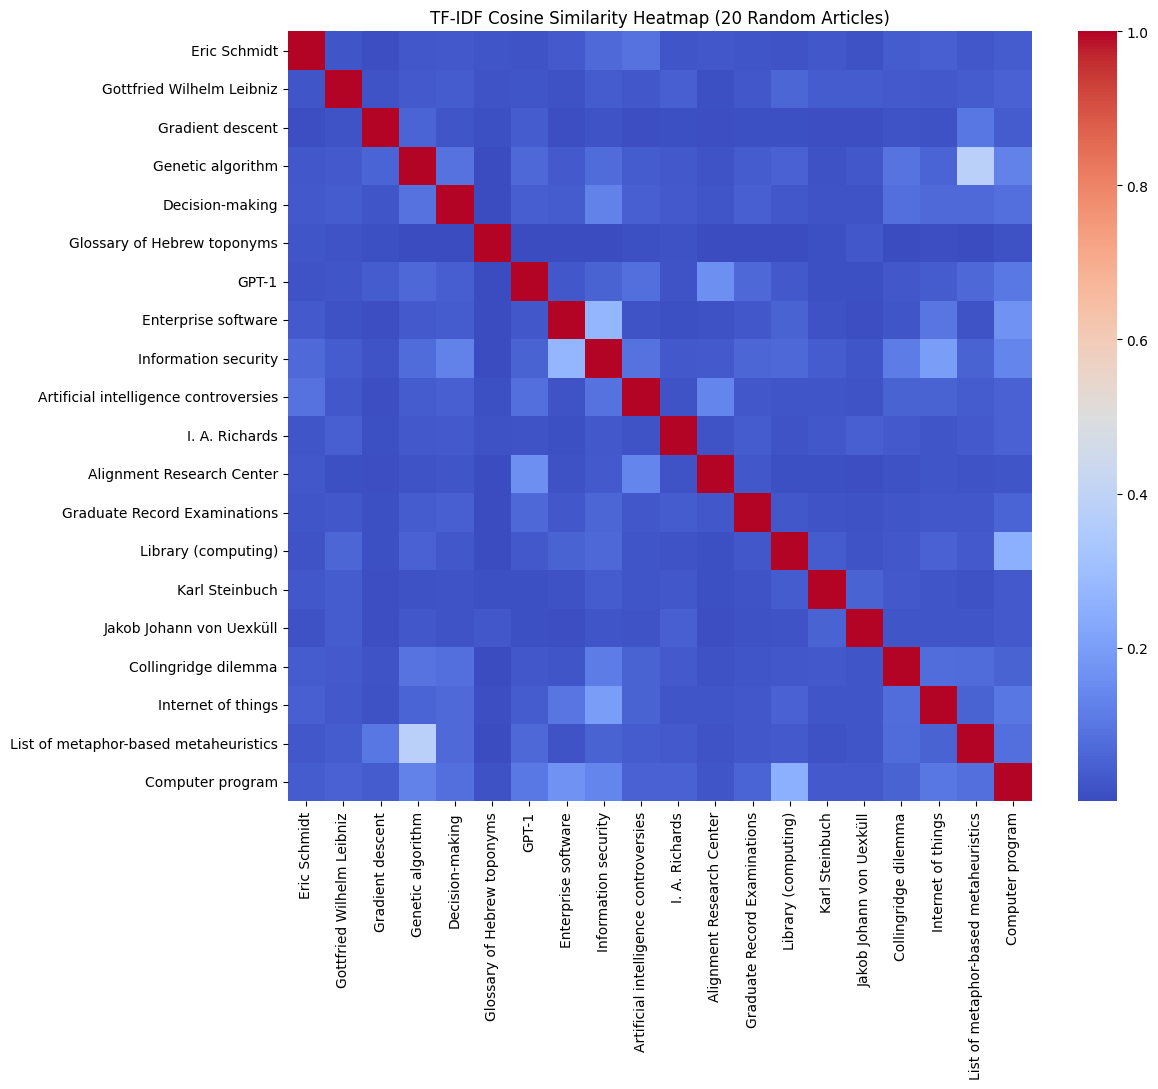

In [30]:
# ---------------------------
# TF-IDF similarity
# ---------------------------
tfidf_vectors = df_tfidf.loc[titles].to_numpy()
tfidf_sim = 1 - np.array([[cosine(v1, v2) for v2 in tfidf_vectors] for v1 in tfidf_vectors])

plt.figure(figsize=(12,10))
sns.heatmap(tfidf_sim, xticklabels=titles, yticklabels=titles, cmap="coolwarm", annot=False)
plt.title("TF-IDF Cosine Similarity Heatmap (20 Random Articles)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

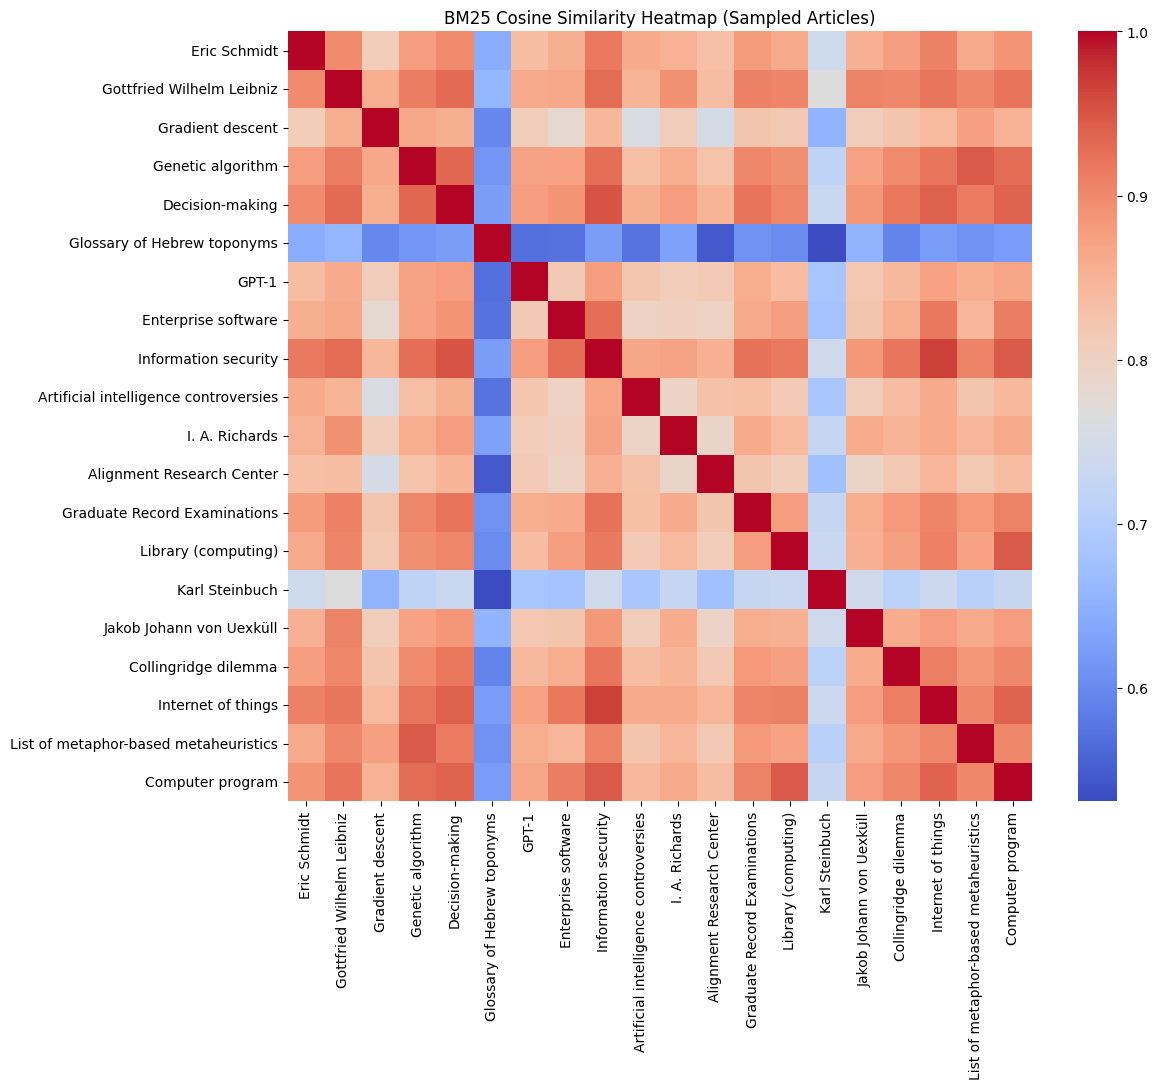

In [43]:
# tokenize corpus of sampled articles
corpus_tokens_sample = [preprocess_for_bm25(t) for t in sample_articles['text']]

# initialize BM25
bm25_sample = BM25Okapi(corpus_tokens_sample)

# compute BM25 vectors only for sampled articles
bm25_vectors_sample = np.array([bm25_sample.get_scores(preprocess_for_bm25(text)) 
                                for text in sample_articles['text']])

# compute cosine similarity between sampled articles
bm25_sim_sample = 1 - np.array([[cosine(v1, v2) for v2 in bm25_vectors_sample] 
                                for v1 in bm25_vectors_sample])

# plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(bm25_sim_sample, 
            xticklabels=sample_articles['article_title'],
            yticklabels=sample_articles['article_title'],
            cmap="coolwarm", annot=False)
plt.title("BM25 Cosine Similarity Heatmap (Sampled Articles)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

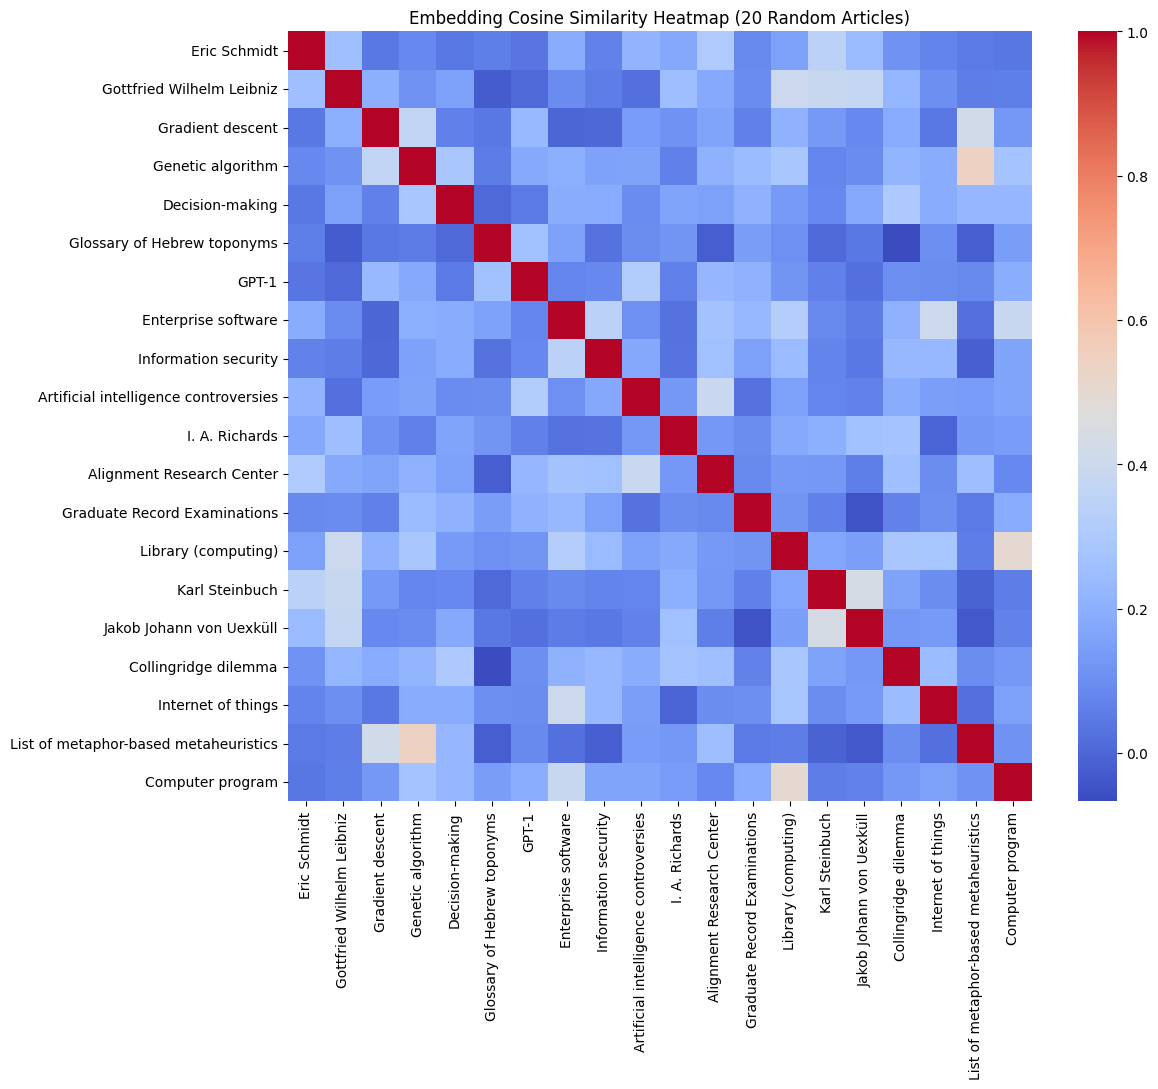

In [33]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')
corpus_texts = df['text'].fillna("").astype(str).tolist()
corpus_embeddings = model.encode(corpus_texts, convert_to_numpy=True)

embed_indices = [df.index.get_loc(df[df['article_title']==t].index[0]) for t in titles]
embed_vectors = corpus_embeddings[embed_indices]

embed_sim = cosine_similarity(embed_vectors)

plt.figure(figsize=(12,10))
sns.heatmap(embed_sim, xticklabels=titles, yticklabels=titles, cmap="coolwarm", annot=False)
plt.title("Embedding Cosine Similarity Heatmap (20 Random Articles)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## 8.PCA

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

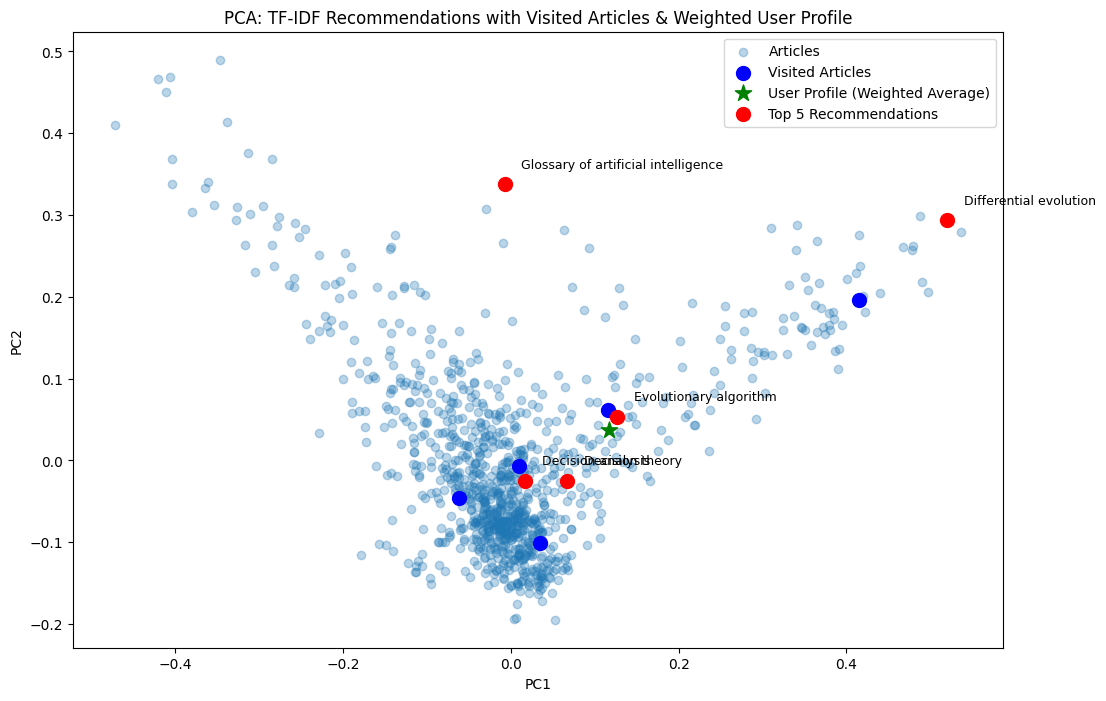

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# TF-IDF recommendations
recommendations_tfidf = recommend_tfidf(visited, df_tfidf, top_n=5)
top5_titles_tfidf = recommendations_tfidf.index.tolist()

# PCA on TF-IDF vectors
pca_tfidf = PCA(n_components=2, random_state=42)
pca_result_tfidf = pca_tfidf.fit_transform(df_tfidf.to_numpy())
df_pca_tfidf = pd.DataFrame(pca_result_tfidf, columns=['PC1','PC2'], index=df_tfidf.index)

# Assign weights to history: more recent articles get higher weight
n = len(visited)
weights = np.linspace(1/n, 1, n)
weights /= weights.sum()

# User profile (weighted average of visited vectors)
visited_vecs_tfidf = df_tfidf.loc[visited].to_numpy()
user_profile_tfidf = np.average(visited_vecs_tfidf, axis=0, weights=weights)
user_profile_pca_tfidf = pca_tfidf.transform(user_profile_tfidf.reshape(1, -1))

# PCA for visited articles individually
visited_pca_tfidf = pca_tfidf.transform(visited_vecs_tfidf)

# Plot
plt.figure(figsize=(12,8))
plt.scatter(df_pca_tfidf['PC1'], df_pca_tfidf['PC2'], alpha=0.3, label='Articles')
plt.scatter(visited_pca_tfidf[:,0], visited_pca_tfidf[:,1], color='blue', s=100, label='Visited Articles')
plt.scatter(user_profile_pca_tfidf[0,0], user_profile_pca_tfidf[0,1], color='green', s=150, marker='*', label='User Profile (Weighted Average)')
plt.scatter(df_pca_tfidf.loc[top5_titles_tfidf,'PC1'], df_pca_tfidf.loc[top5_titles_tfidf,'PC2'], color='red', s=100, label='Top 5 Recommendations')

for title in top5_titles_tfidf:
    plt.text(df_pca_tfidf.loc[title,'PC1']+0.02, df_pca_tfidf.loc[title,'PC2']+0.02, title, fontsize=9)

plt.title("PCA: TF-IDF Recommendations with Visited Articles & Weighted User Profile")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

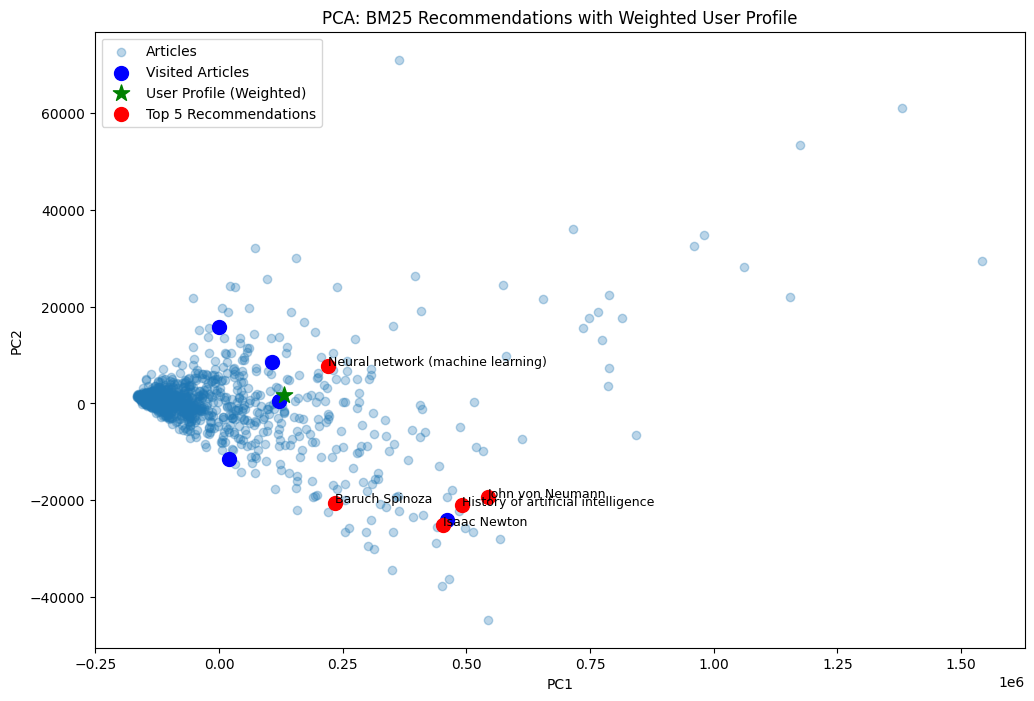

In [44]:
# BM25 recommendations
recommendations_bm25 = bm25_recommend(visited, df, top_n=5)
top5_titles_bm25 = recommendations_bm25.index.tolist()

# BM25 vectors for all articles
corpus_tokens_bm25 = [preprocess_for_bm25(text) for text in df['text']]
bm25_full = BM25Okapi(corpus_tokens_bm25)
bm25_vectors_full = np.array([bm25_full.get_scores(preprocess_for_bm25(text)) for text in df['text']])
df_bm25_vectors = pd.DataFrame(bm25_vectors_full, index=df['article_title'])

# PCA on BM25 vectors
pca_bm25 = PCA(n_components=2, random_state=42)
df_pca_bm25 = pd.DataFrame(pca_bm25.fit_transform(df_bm25_vectors.to_numpy()),
                           columns=['PC1','PC2'], index=df_bm25_vectors.index)

# Weighted user profile
visited_vecs_bm25 = df_bm25_vectors.loc[visited].to_numpy()
n = len(visited_vecs_bm25)
weights = np.linspace(1/n, 1, n)
weights /= weights.sum()
user_profile_bm25 = np.average(visited_vecs_bm25, axis=0, weights=weights).reshape(1, -1)

# PCA transforms
visited_pca_bm25 = pca_bm25.transform(visited_vecs_bm25)
user_profile_pca_bm25 = pca_bm25.transform(user_profile_bm25)

# Plot
plt.figure(figsize=(12,8))
plt.scatter(df_pca_bm25['PC1'], df_pca_bm25['PC2'], alpha=0.3, label='Articles')
plt.scatter(visited_pca_bm25[:,0], visited_pca_bm25[:,1], color='blue', s=100, label='Visited Articles')
plt.scatter(user_profile_pca_bm25[0,0], user_profile_pca_bm25[0,1], color='green', s=150, marker='*', label='User Profile (Weighted)')
plt.scatter(df_pca_bm25.loc[top5_titles_bm25,'PC1'], df_pca_bm25.loc[top5_titles_bm25,'PC2'], color='red', s=100, label='Top 5 Recommendations')

for title in top5_titles_bm25:
    plt.text(df_pca_bm25.loc[title,'PC1']+0.02, df_pca_bm25.loc[title,'PC2']+0.02, title, fontsize=9)

plt.title("PCA: BM25 Recommendations with Weighted User Profile")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

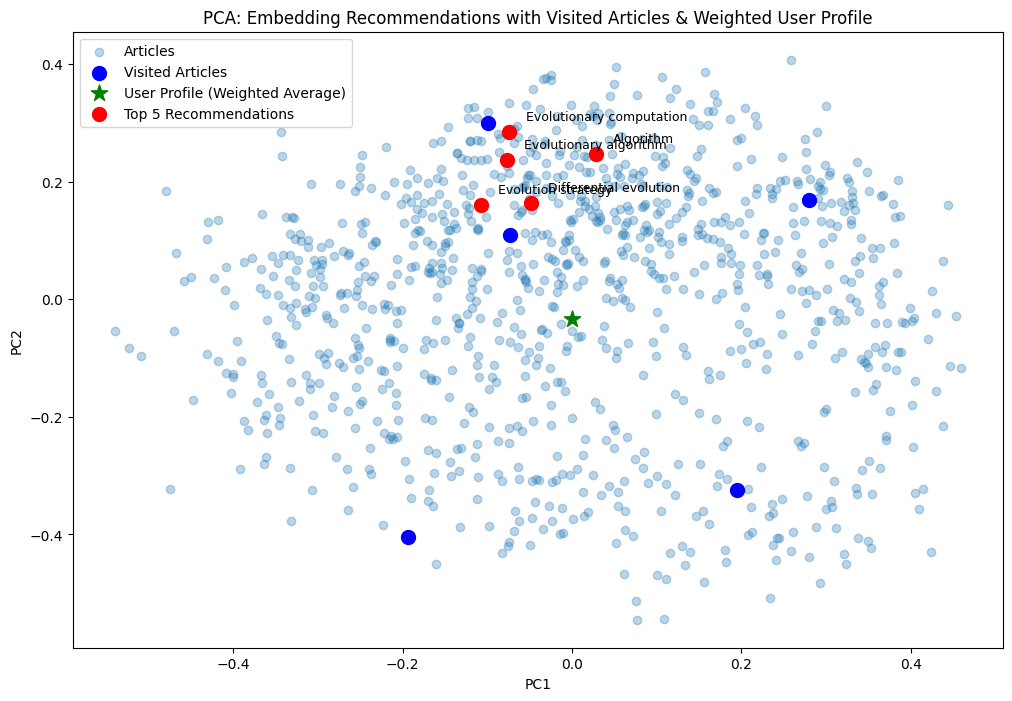

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Embedding recommendations with weighted history
recommendations_embed, corpus_embeddings = embed_recommend(visited, df, top_n=5)
top5_titles_embed = recommendations_embed.index.tolist()

# Embeddings for visited articles
visited_texts = df.loc[df['article_title'].isin(visited), 'text'].fillna("").astype(str).tolist()
visited_embeddings = model.encode(visited_texts, convert_to_numpy=True)

# Assign weights to history: more recent articles get higher weight
n = len(visited_embeddings)
weights = np.linspace(1/n, 1, n)
weights /= weights.sum()

# Weighted average for user profile
user_profile_embed = np.average(visited_embeddings, axis=0, weights=weights).reshape(1, -1)

# PCA on all embeddings
pca_embed = PCA(n_components=2, random_state=42)
pca_result_embed = pca_embed.fit_transform(corpus_embeddings)
df_pca_embed = pd.DataFrame(pca_result_embed, columns=['PC1','PC2'], index=df['article_title'])

# PCA for visited articles individually
visited_pca_embed = pca_embed.transform(visited_embeddings)
user_profile_pca_embed = pca_embed.transform(user_profile_embed)

# Plot
plt.figure(figsize=(12,8))
plt.scatter(df_pca_embed['PC1'], df_pca_embed['PC2'], alpha=0.3, label='Articles')
plt.scatter(visited_pca_embed[:,0], visited_pca_embed[:,1], color='blue', s=100, label='Visited Articles')
plt.scatter(user_profile_pca_embed[0,0], user_profile_pca_embed[0,1], color='green', s=150, marker='*', label='User Profile (Weighted Average)')
plt.scatter(df_pca_embed.loc[top5_titles_embed,'PC1'], df_pca_embed.loc[top5_titles_embed,'PC2'], color='red', s=100, label='Top 5 Recommendations')

for title in top5_titles_embed:
    plt.text(df_pca_embed.loc[title,'PC1']+0.02, df_pca_embed.loc[title,'PC2']+0.02, title, fontsize=9)

plt.title("PCA: Embedding Recommendations with Visited Articles & Weighted User Profile")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## 9. Comparison of Recommendation Methods

We tested **three recommendation approaches** on our Wikipedia article dataset: TF-IDF, BM25, and embedding-based methods using a pre-trained SentenceTransformer model. Each method was visualized with PCA, showing the visited articles, the user profile (average of visited articles), and the top recommended articles.

**Observations:**

- **TF-IDF** was the **fastest** method and provides a simple, interpretable baseline. Its similarity heatmaps generally show **lower overall similarity** values between articles, reflecting its strict word-matching nature.
- **BM25** produced **higher similarity scores**, capturing term frequency and document length effects more effectively than plain TF-IDF.
- **Embedding-based recommendations** cover a **full range of similarity values**, allowing more flexible and semantically meaningful queries. Personal testing and qualitative evaluation suggest that embeddings often provide the **most relevant recommendations** according to human judgment, though no objective accuracy metric is easily defined.

Overall, while TF-IDF and BM25 are solid baselines, **embedding models provide better semantic understanding**, making them preferable for real-world recommendation tasks where meaning and context matter.